# Titanic Survival Prediction using Machine Learning and Exploratory Data Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df=pd.read_excel(r"C:\Users\Admin\Documents\GitHub\Python-Project\Titanic Survival\Titanic Dataset.xlsx")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Data Cleaning

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Text(0.5, 1.0, 'Missing Values')

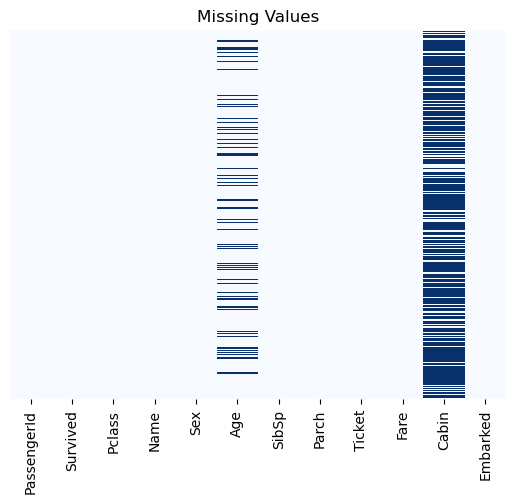

In [9]:
# Missing Value Analysis
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='Blues')

plt.title(
"Missing Values"
)

**This code creates a missing values heatmap to visually identify where null (missing) values exist in your dataset.**

Age contains missing values.

Cabin heavily missing.

Embarked few missing.

In [10]:
#Drop Cabin (too many missing), PassengerId, Ticket (low usefulness)
df.drop(['Ticket','Cabin',],axis=1,inplace=True)


**PassengerId → Dropped because it is only an ID number and does not help predict survival,Machine Learning models usually do not benefit from ID columns.**

**Ticket → Dropped because ticket numbers usually do not provide useful information for the model.**

**Cabin → Dropped because it contains many missing (null) values.**

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64

In [12]:
df['Embarked']=df['Embarked'].fillna(value='S')

**Why 'S'?**

**S appears most frequently, so replacing missing values with 'S' is a common preprocessing technique.**

In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64

In [14]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

**S = Southampton**

**C = Cherbourg**

**Q = Queenstown**

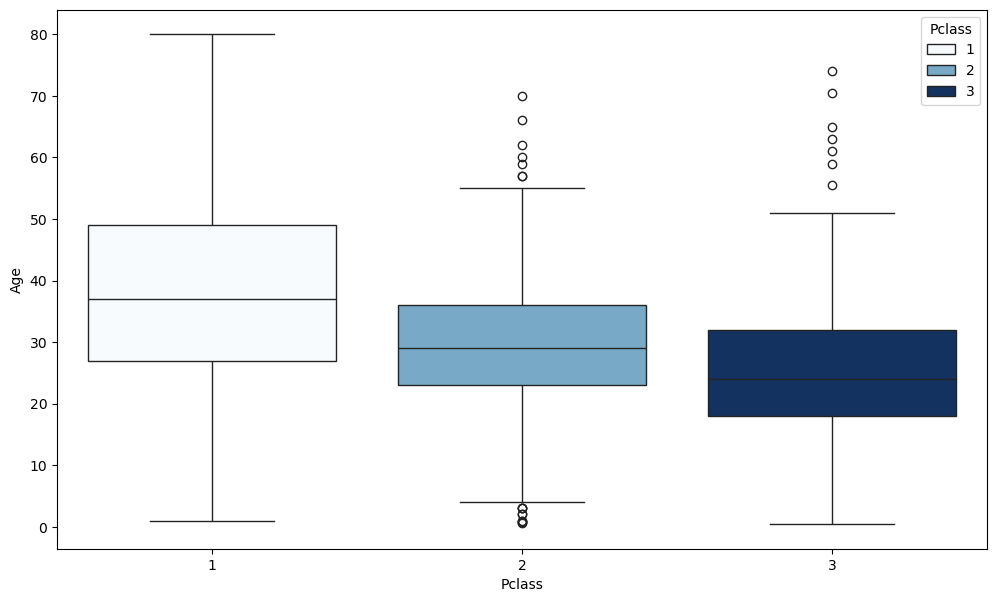

In [15]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass',y='Age',hue='Pclass',data=df,palette='Blues')
plt.show()

**Fill missing Age values using Passenger Class information instead of dropping rows.**

In [16]:
def impute_age(cols):
    Age=cols['Age']
    Pclass=cols['Pclass']
    
    if pd.isnull(Age):
        if Pclass==1:
            return 37
        elif Pclass==2:
            return 29
        else:
            return 24
    else:
        return Age
    

In [17]:
df['Age'] = df[['Age','Pclass']].apply(impute_age,axis=1)

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [21]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.00,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.00,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,7.75,Q


## Feature Engineering

**Create a new useful feature (Title) from Name to improve Machine Learning prediction. This is called Feature Engineering.**

In [22]:
# Extract title from passenger name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Check extracted titles
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [23]:
## Replace rare titles
df['Title'] = df['Title'].replace(
['Lady','Countess','Capt','Col','Don','Dr',
'Major','Rev','Sir','Jonkheer','Dona'],
'Rare'
)

# Standardize Miss/Ms/Mlle and Mrs/Mme
df['Title'] = df['Title'].replace(
['Mlle','Ms'],
'Miss'
)

df['Title'] = df['Title'].replace(
'Mme',
'Mrs'
)

In [24]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [25]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,Rare
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,23.4500,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,Mr


In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr


In [27]:
# Drop Name
df.drop("Name",axis=1,inplace=True)

In [28]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,male,22.0,1,0,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,8.0500,S,Mr


**FamilyStatus to identify whether a passenger was traveling alone or with family.**

In [29]:
df['FamilyStatus']=df.apply(lambda row:'Alone' if(row['SibSp']==0 and row['Parch']==0) else "Family",axis=1)

In [30]:
df['FamilyStatus'].value_counts()

FamilyStatus
Alone     537
Family    354
Name: count, dtype: int64

**FareBand feature by dividing the Fare column into 4 equal-sized bins (quartiles):**

In [31]:

df['FareBand']=pd.qcut(
df['Fare'],
4
)

In [32]:
df['FareBand']

0       (-0.001, 7.91]
1      (31.0, 512.329]
2       (7.91, 14.454]
3      (31.0, 512.329]
4       (7.91, 14.454]
            ...       
886     (7.91, 14.454]
887     (14.454, 31.0]
888     (14.454, 31.0]
889     (14.454, 31.0]
890     (-0.001, 7.91]
Name: FareBand, Length: 891, dtype: category
Categories (4, interval[float64, right]): [(-0.001, 7.91] < (7.91, 14.454] < (14.454, 31.0] < (31.0, 512.329]]

In [33]:
df['FareBand'].value_counts()

FareBand
(7.91, 14.454]     224
(-0.001, 7.91]     223
(14.454, 31.0]     222
(31.0, 512.329]    222
Name: count, dtype: int64

**creating a new feature (AgeGroup) from an existing feature (Age).**

In [34]:
df['AgeGroup']=pd.cut(
df['Age'],
bins=[0,12,18,35,60,100],

labels=[
'Child',
'Teen',
'Adult',
'MiddleAge',
'Senior'
]
)

In [35]:
df['AgeGroup'].value_counts()

AgeGroup
Adult        505
MiddleAge    225
Teen          70
Child         69
Senior        22
Name: count, dtype: int64

In [36]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilyStatus,FareBand,AgeGroup
0,1,0,3,male,22.0,1,0,7.2500,S,Mr,Family,"(-0.001, 7.91]",Adult
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs,Family,"(31.0, 512.329]",MiddleAge
2,3,1,3,female,26.0,0,0,7.9250,S,Miss,Alone,"(7.91, 14.454]",Adult
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs,Family,"(31.0, 512.329]",Adult
4,5,0,3,male,35.0,0,0,8.0500,S,Mr,Alone,"(7.91, 14.454]",Adult


In [39]:
df.to_excel('cleaned_Titanic_Dataset.xlsx')

## EDA

In [40]:
df=pd.read_excel('cleaned_Titanic_Dataset.xlsx')

In [41]:
df.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilyStatus,FareBand,AgeGroup
0,0,1,0,3,male,22.0,1,0,7.2500,S,Mr,Family,"(-0.001, 7.91]",Adult
1,1,2,1,1,female,38.0,1,0,71.2833,C,Mrs,Family,"(31.0, 512.329]",MiddleAge
2,2,3,1,3,female,26.0,0,0,7.9250,S,Miss,Alone,"(7.91, 14.454]",Adult
3,3,4,1,1,female,35.0,1,0,53.1000,S,Mrs,Family,"(31.0, 512.329]",Adult
4,4,5,0,3,male,35.0,0,0,8.0500,S,Mr,Alone,"(7.91, 14.454]",Adult


## Univeariate Analysis-Numerical

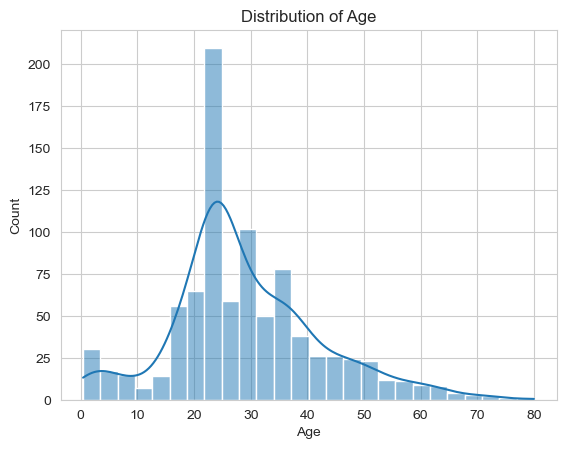

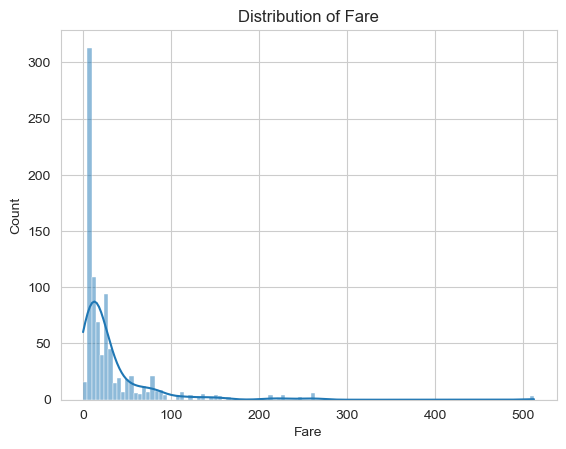

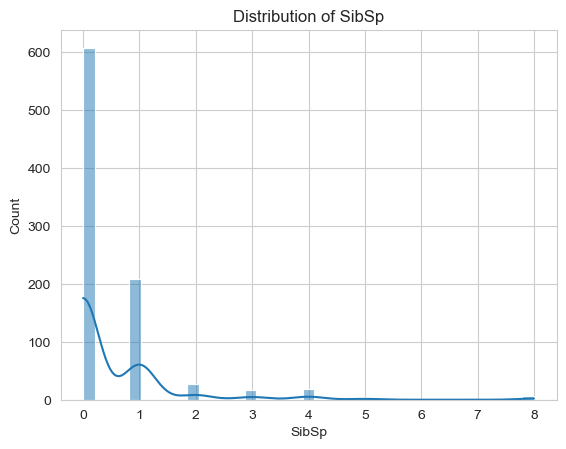

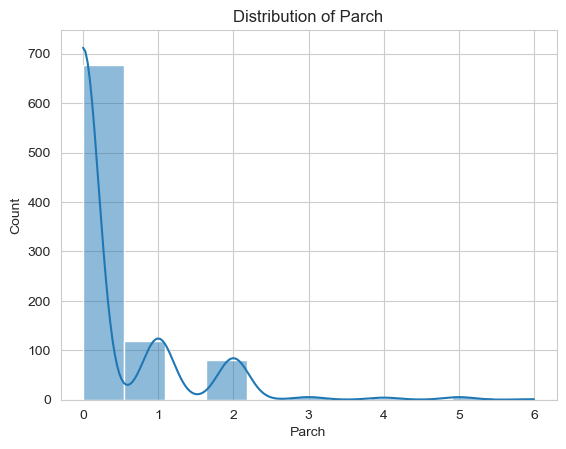

In [126]:
num_cols=['Age','Fare','SibSp','Parch']

for col in num_cols:

    plt.figure()

    sns.histplot(
    df[col],
    kde=True
    )

    plt.title(
    f"Distribution of {col}"
    )

    plt.show()

**Majority of passengers were adults, with fewer elderly passengers onboard.**

**Most passengers traveled with lower ticket fares, while only a small number paid premium fares.**

**Most passengers traveled alone or with a small family group.Large family groups were uncommon.**

**The majority of passengers traveled without parents or children.Fewer passengers traveled with family members.**

## Univariate Analysis - Categorical

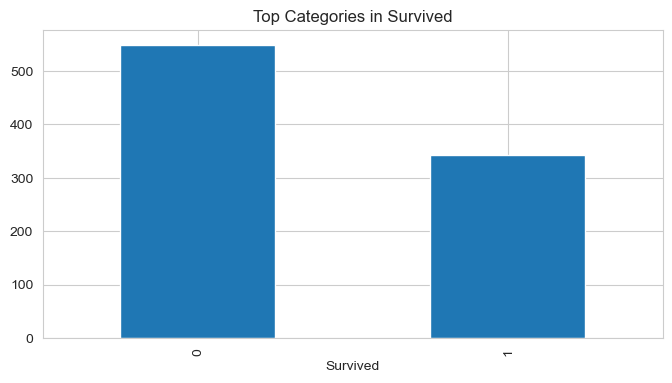

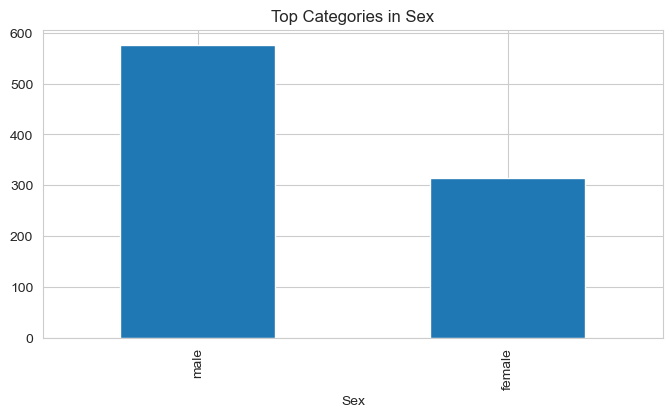

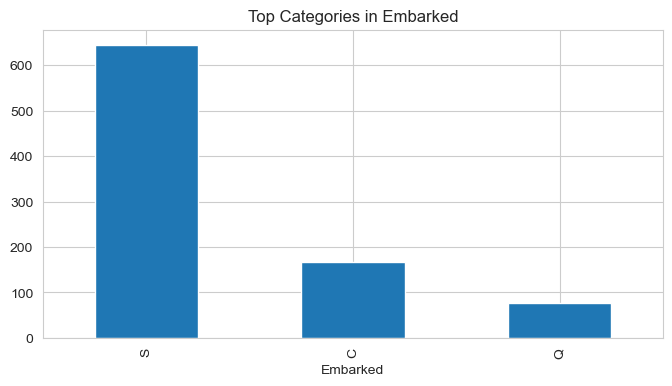

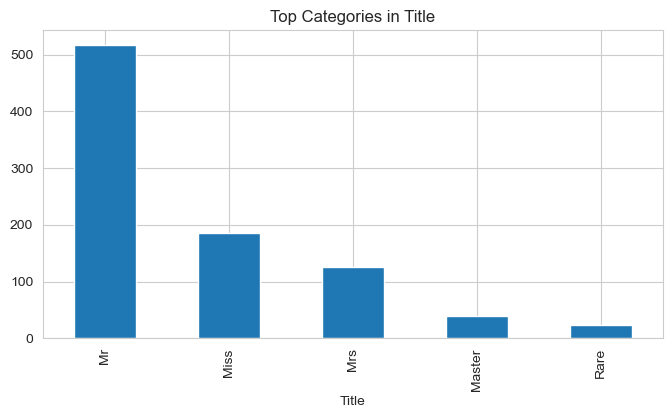

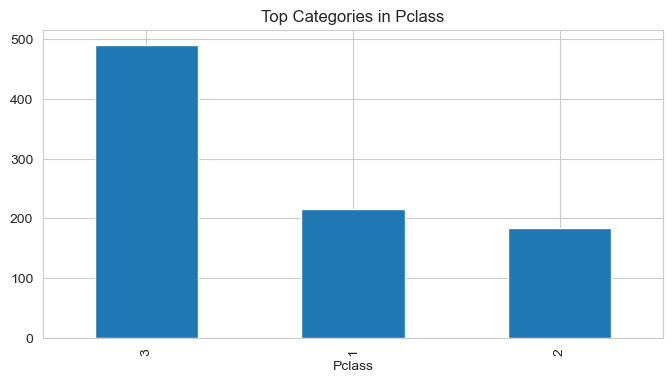

In [127]:
cat_cols = ['Survived','Sex','Embarked','Title','Pclass']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.show()

**More passengers did not survive than survived.**

**Male passengers were higher than female passengers.**

**Most passengers boarded from Southampton (S).Cherbourg (C) and Queenstown (Q) had fewer passengers.**

**'Mr' was the most common title.'Miss' and 'Mrs' followed.Rare titles appeared very less frequently.**

**Most passengers belonged to Third Class.First Class passengers were comparatively fewer.**





## Bivariate Analysis

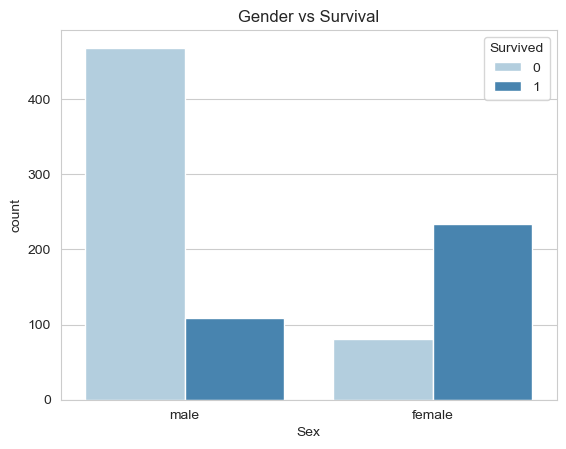

In [128]:
sns.countplot(
x='Sex',hue='Survived',data=df,palette='Blues')

plt.title("Gender vs Survival")


plt.show()

In [129]:
survival_gender=df.groupby('Sex')['Survived'].value_counts()

In [130]:
survival_gender

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

**Female survival rate higher.**

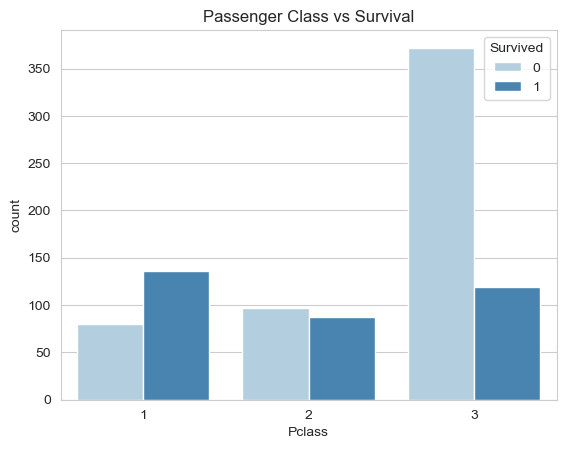

In [131]:
sns.countplot(
x='Pclass',hue='Survived',data=df,palette='Blues')

plt.title("Passenger Class vs Survival")


plt.show()

In [132]:
survival_Pclass=df.groupby(['Sex','Pclass'])['Survived'].value_counts()

In [133]:
survival_Pclass

Sex     Pclass  Survived
female  1       1            91
                0             3
        2       1            70
                0             6
        3       0            72
                1            72
male    1       0            77
                1            45
        2       0            91
                1            17
        3       0           300
                1            47
Name: count, dtype: int64

**First class survival rate higher.**

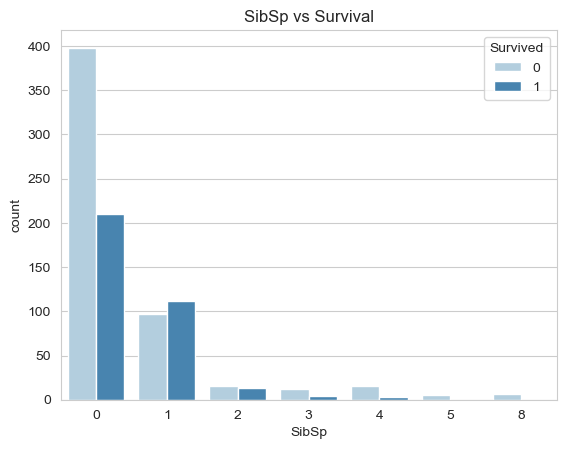

In [134]:
sns.countplot(
x='SibSp',hue='Survived',data=df,palette='Blues')

plt.title("SibSp vs Survival")


plt.show()

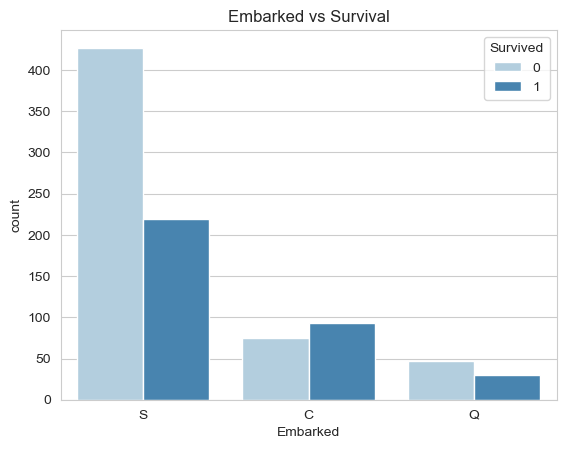

In [135]:
sns.countplot(
x='Embarked',hue='Survived',data=df,palette='Blues')

plt.title("Embarked vs Survival")


plt.show()

In [136]:
survival_Embarked=df.groupby(['Embarked'])['Survived'].value_counts()

In [137]:
survival_Embarked

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           219
Name: count, dtype: int64

**Passenger survival varied by embarkation location.**
** Southampton

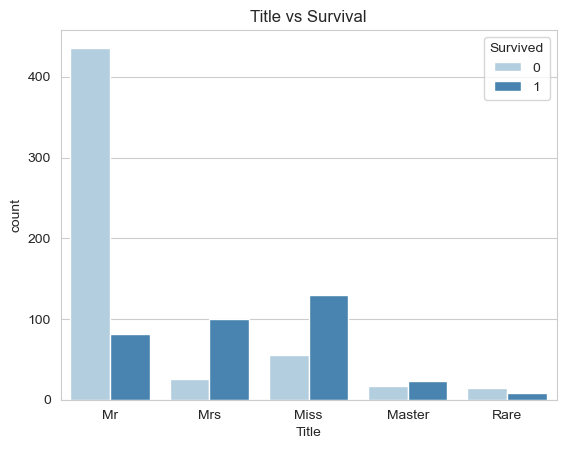

In [143]:
sns.countplot(
x='Title',hue='Survived',data=df,palette='Blues')

plt.title("Title vs Survival")


plt.show()

In [144]:
survival_Title=df.groupby('Title')['Survived'].value_counts()

In [145]:
survival_Title

Title   Survived
Master  1            23
        0            17
Miss    1           130
        0            55
Mr      0           436
        1            81
Mrs     1           100
        0            26
Rare    0            15
        1             8
Name: count, dtype: int64

**Female-related titles had better survival rates.**

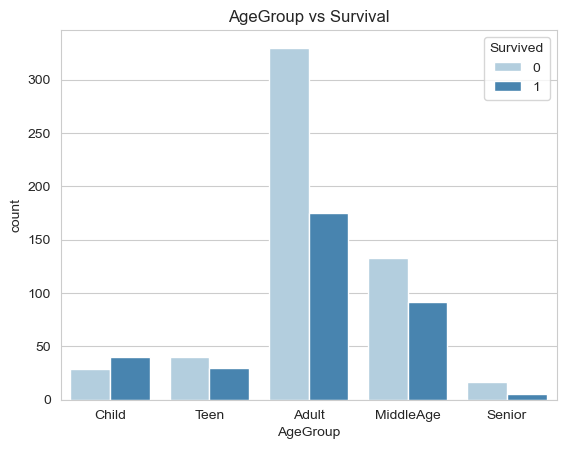

In [146]:
sns.countplot(
x='AgeGroup',hue='Survived',data=df,palette='Blues')

plt.title("AgeGroup vs Survival")


plt.show()

In [147]:
survival_AgeGroup=df.groupby('AgeGroup',observed=False)['Survived'].value_counts()

In [148]:
survival_AgeGroup

AgeGroup   Survived
Child      1            40
           0            29
Teen       0            40
           1            30
Adult      0           330
           1           175
MiddleAge  0           133
           1            92
Senior     0            17
           1             5
Name: count, dtype: int64

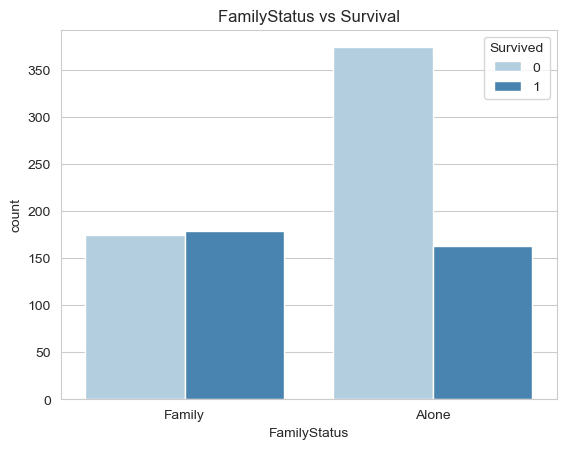

In [149]:
sns.countplot(
x='FamilyStatus',hue='Survived',data=df,palette='Blues')

plt.title("FamilyStatus vs Survival")


plt.show()

In [150]:
survival_FamilyStatus=df.groupby('FamilyStatus',observed=False)['Survived'].value_counts()

In [151]:
survival_FamilyStatus

FamilyStatus  Survived
Alone         0           374
              1           163
Family        1           179
              0           175
Name: count, dtype: int64

**Passengers with family survived more.**

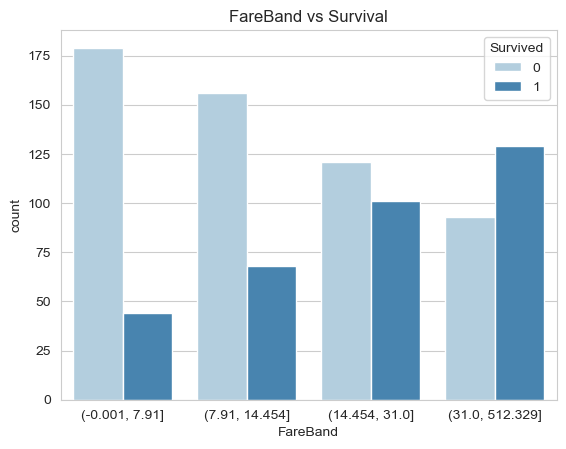

In [152]:
sns.countplot(x='FareBand',hue='Survived',data=df,palette='Blues')

plt.title("FareBand vs Survival")


plt.show()

In [153]:
survival_FareBand=df.groupby('FareBand',observed=False)['Survived'].value_counts()

In [154]:
survival_FareBand


FareBand         Survived
(-0.001, 7.91]   0           179
                 1            44
(7.91, 14.454]   0           156
                 1            68
(14.454, 31.0]   0           121
                 1           101
(31.0, 512.329]  1           129
                 0            93
Name: count, dtype: int64

**Passengers paying higher fares survived more.**

## Target Analysis

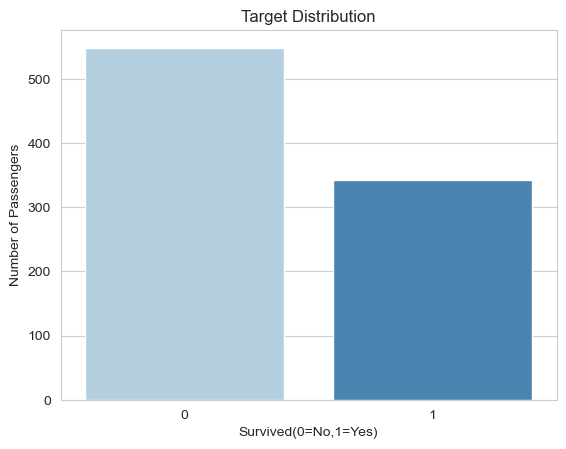

In [155]:
sns.countplot(x='Survived',hue='Survived',legend=False,data=df,palette='Blues')

plt.title("Target Distribution")
plt.xlabel("Survived(0=No,1=Yes)")
plt.ylabel("Number of Passengers")

sns.set_style('whitegrid')

plt.show()

In [156]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

**More passengers did not survive than survived.**

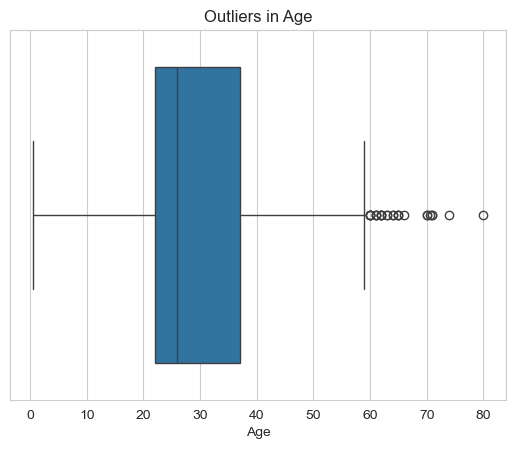

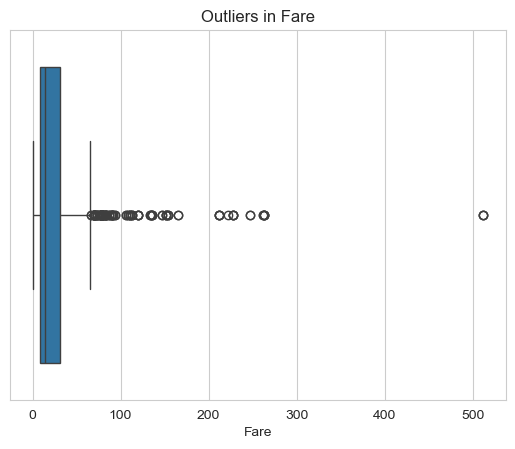

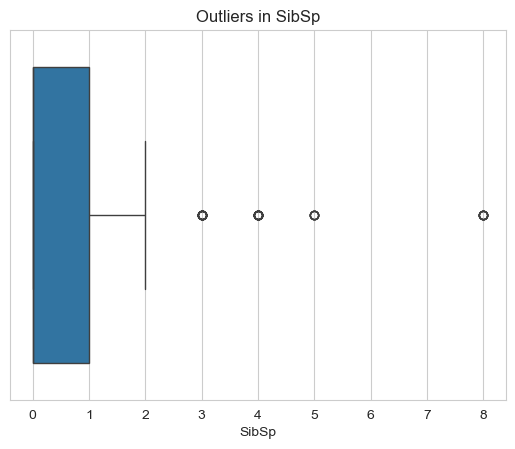

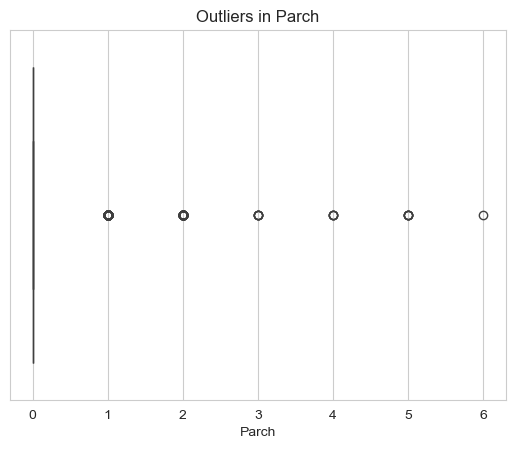

In [157]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

**Fare positively correlates with survival.**

Higher fares were usually paid by First Class passengers

**Pclass negatively correlates with survival.**

**Why?**

First-class passengers had better cabin locations.

Better access to lifeboats.

Higher socioeconomic status.

In [163]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in ['Sex','Embarked','Title','FamilyStatus']:

    df[col]=\
    le.fit_transform(df[col])

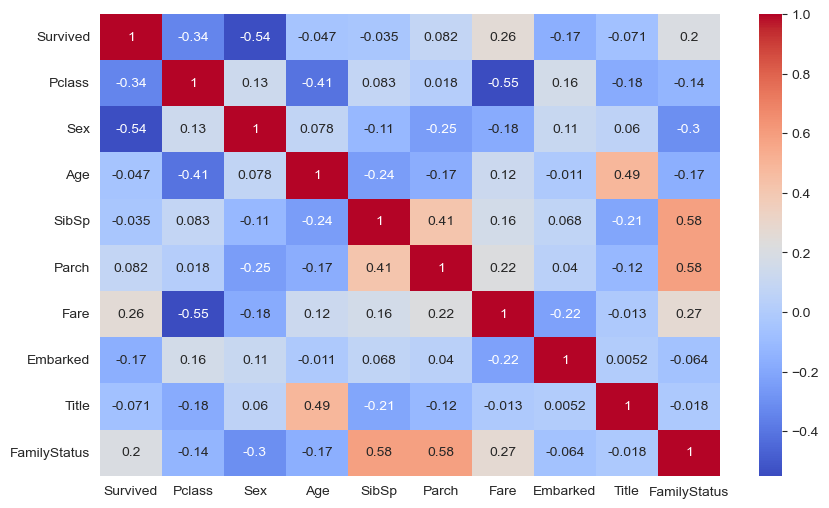

In [162]:
#Correlation:

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

plt.show()